# Feature 1 — HMM 소음 대비 신호 국면 판별기 v2

Shiller/FRED/yfinance 데이터 → 8개 이성/감정 지표 → HMM(4상태) → 국면 판별

| rank | 국면 | 의미 |
|------|------|------|
| 0 | 펀더멘털 반영 | 주가가 실적·데이터를 충실히 반영 |
| 1 | 펀더멘털 약반영 | 대체로 논리적, 센티멘트 일부 혼재 |
| 2 | 센티멘트 약반영 | 심리·감정이 데이터보다 앞서는 구간 |
| 3 | 센티멘트 지배 | 펀더멘털과 무관하게 움직이는 구간 |

In [ ]:
# ── Cell 1: 환경 설정 + 상수 정의 ──────────────────────────────────────────
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import yfinance as yf
import requests, time
from io import StringIO

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import RobustScaler

from dotenv import load_dotenv
load_dotenv('../.env')

# 한글 폰트 (Windows)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# ── 상수 ──
N_STATES = 4
PHASE_NAMES  = {0: '🧠 펀더멘털 반영', 1: '⚖️ 펀더멘털 약반영', 2: '🌊 센티멘트 약반영', 3: '🔥 센티멘트 지배'}
PHASE_COLORS = {0: '#4CAF50', 1: '#8BC34A', 2: '#FF9800', 3: '#F44336'}
RANK_TO_PHASE = [0, 1, 2, 3]  # noise_score 오름차순

FEATURE_NAMES = ['fundamental_gap', 'erp_zscore', 'residual_corr',
                 'dispersion', 'amihud', 'vix_term', 'hy_spread',
                 'realized_vol']

HEADERS = {'User-Agent': 'Mozilla/5.0'}

print('환경 설정 완료')
print(f'국면: {list(PHASE_NAMES.values())}')
print(f'피처: {FEATURE_NAMES}')

환경 설정 완료
국면: ['🧠 펀더멘털 반영', '⚖️ 펀더멘털 약반영', '🌊 센티멘트 약반영', '🔥 센티멘트 지배']
피처: ['fundamental_gap', 'erp_zscore', 'residual_corr', 'dispersion', 'amihud', 'vix_term', 'hy_spread', 'realized_vol']


Shiller ie_data.xls 다운로드 중...
  ✓ CAPE 컬럼: CAPE

S&P 500 Yahoo Finance 보완 데이터 수집 중...
  Shiller 최종: 1871-01-01 ~ 2026-03-01 (1711개월)

변수 ① 펀더멘털 괴리: 1699개월
  기간: 1872-02-01 ~ 2026-03-01
  평균: 0.0079  |  표준편차: 0.2864


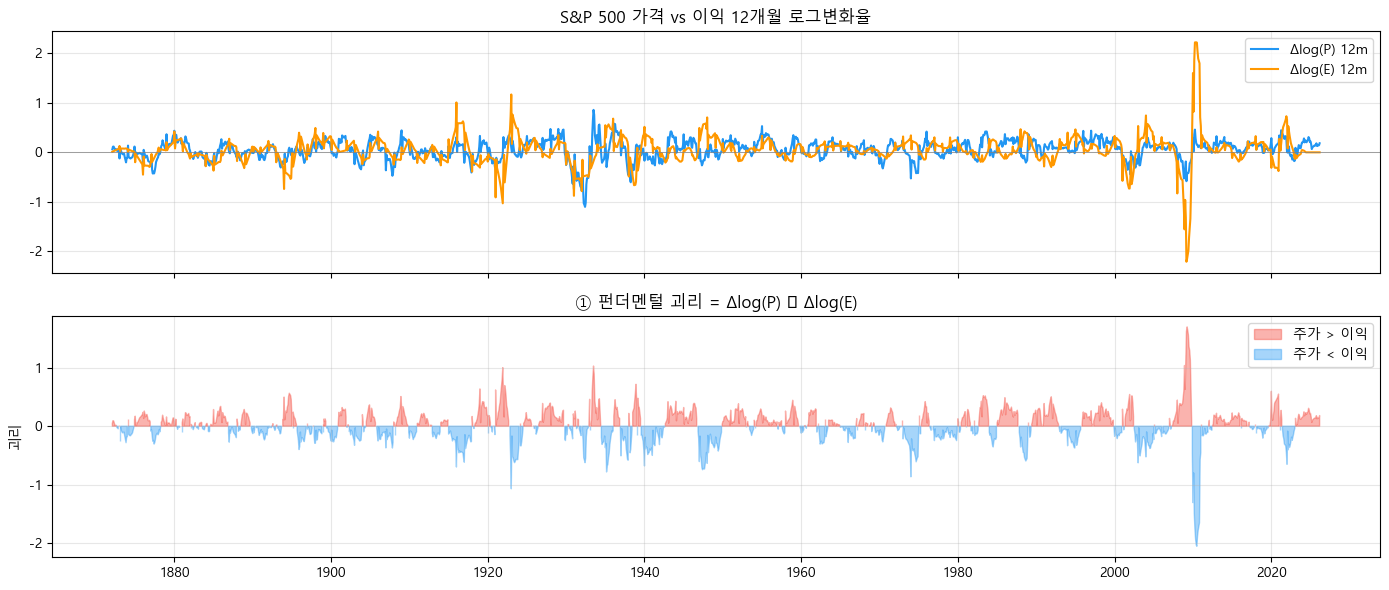

In [ ]:
# ── Cell 2: Shiller 월별 데이터 수집 (P, E, CAPE) ──────────────────────────
# Robert Shiller ie_data.xls: 1871년~ 월별 S&P 500 Price, Earnings, CAPE
SHILLER_URL = 'http://www.econ.yale.edu/~shiller/data/ie_data.xls'

print('Shiller ie_data.xls 다운로드 중...')
shiller = pd.read_excel(SHILLER_URL, sheet_name='Data', skiprows=7, header=0)

cols = shiller.columns.tolist()
shiller = shiller.rename(columns={cols[0]: 'date_raw', cols[1]: 'P', cols[3]: 'E'})

# CAPE 컬럼 찾기
cape_col = None
for c in cols:
    if isinstance(c, str) and 'cape' in c.lower():
        cape_col = c
        break
    if isinstance(c, str) and 'cyclically' in c.lower():
        cape_col = c
        break

if cape_col is None:
    print('  ⚠ CAPE 컬럼 자동감지 실패 → P/E10으로 직접 계산')
    cape_available = False
else:
    shiller = shiller.rename(columns={cape_col: 'CAPE'})
    cape_available = True
    print(f'  ✓ CAPE 컬럼: {cape_col}')

# 날짜 파싱
def parse_shiller_date(val):
    try:
        s = str(val)
        parts = s.split('.')
        year = int(parts[0])
        month = int(parts[1]) if len(parts) > 1 and parts[1] else 1
        month = max(1, min(12, month))
        return pd.Timestamp(year=year, month=month, day=1)
    except:
        return pd.NaT

shiller['date'] = shiller['date_raw'].apply(parse_shiller_date)
shiller = shiller.dropna(subset=['date'])
shiller = shiller.set_index('date')
shiller = shiller[~shiller.index.duplicated(keep='last')]
shiller = shiller.sort_index()

# 숫자 변환
for col in ['P', 'E']:
    shiller[col] = pd.to_numeric(shiller[col], errors='coerce')
if cape_available:
    shiller['CAPE'] = pd.to_numeric(shiller['CAPE'], errors='coerce')

# ★ P가 끊기는 최신 구간을 Yahoo Finance S&P 500으로 보완
print('\nS&P 500 Yahoo Finance 보완 데이터 수집 중...')
def _fetch_yahoo(ticker, years=3):
    today = datetime.date.today()
    from_date = today - datetime.timedelta(days=365 * years)
    epoch = datetime.datetime(1970, 1, 1)
    from_ts = int((datetime.datetime.combine(from_date, datetime.time()) - epoch).total_seconds())
    to_ts   = int((datetime.datetime.combine(today,     datetime.time()) - epoch).total_seconds())
    url = f'https://query1.finance.yahoo.com/v8/finance/chart/{ticker}'
    params = {'interval': '1mo', 'period1': from_ts, 'period2': to_ts}
    resp = requests.get(url, params=params, headers=HEADERS, timeout=15)
    resp.raise_for_status()
    result = resp.json()['chart']['result'][0]
    timestamps = result['timestamp']
    closes = result['indicators']['adjclose'][0]['adjclose']
    index = pd.to_datetime(timestamps, unit='s').normalize()
    return pd.Series(closes, index=index, name='P')

sp_yahoo = _fetch_yahoo('^GSPC')
sp_yahoo.index = sp_yahoo.index.to_period('M').to_timestamp()  # 월초 정규화

# Shiller P가 NaN인 최신 구간을 Yahoo로 채움
last_shiller_p = shiller['P'].dropna().index[-1]
new_months = sp_yahoo[sp_yahoo.index > last_shiller_p]
for dt, price in new_months.items():
    if dt not in shiller.index:
        shiller.loc[dt] = np.nan
    shiller.loc[dt, 'P'] = price
shiller = shiller.sort_index()

# E: forward-fill (최신 몇 달은 아직 미발표)
shiller['E'] = shiller['E'].ffill()

# CAPE: 없는 구간은 P / E10 (10년 평균 E)으로 계산
e10 = shiller['E'].rolling(120, min_periods=60).mean()
if cape_available:
    shiller['CAPE'] = shiller['CAPE'].fillna(shiller['P'] / e10)
else:
    shiller['CAPE'] = shiller['P'] / e10
    cape_available = True

shiller = shiller[shiller['P'].notna() & shiller['E'].notna()]

print(f'  Shiller 최종: {shiller.index[0].date()} ~ {shiller.index[-1].date()} ({len(shiller)}개월)')

# ── 변수 ① 펀더멘털 괴리: Δlog(P)_12m − Δlog(E)_12m ──
shiller['log_P'] = np.log(shiller['P'])
shiller['log_E'] = np.log(shiller['E'].clip(lower=0.01))

fundamental_gap = shiller['log_P'].diff(12) - shiller['log_E'].diff(12)
fundamental_gap = fundamental_gap.dropna()
fundamental_gap.name = 'fundamental_gap'

print(f'\n변수 ① 펀더멘털 괴리: {len(fundamental_gap)}개월')
print(f'  기간: {fundamental_gap.index[0].date()} ~ {fundamental_gap.index[-1].date()}')
print(f'  평균: {fundamental_gap.mean():.4f}  |  표준편차: {fundamental_gap.std():.4f}')

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(shiller.index, shiller['log_P'].diff(12), label='Δlog(P) 12m', color='#2196F3')
axes[0].plot(shiller.index, shiller['log_E'].diff(12), label='Δlog(E) 12m', color='#FF9800')
axes[0].legend()
axes[0].set_title('S&P 500 가격 vs 이익 12개월 로그변화율')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].grid(alpha=0.3)

axes[1].fill_between(fundamental_gap.index, fundamental_gap, 0,
                     where=fundamental_gap > 0, color='#F44336', alpha=0.4, label='주가 > 이익')
axes[1].fill_between(fundamental_gap.index, fundamental_gap, 0,
                     where=fundamental_gap <= 0, color='#2196F3', alpha=0.4, label='주가 < 이익')
axes[1].set_title('① 펀더멘털 괴리 = Δlog(P) − Δlog(E)')
axes[1].set_ylabel('괴리')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 3: FRED 데이터 일괄 수집 ──────────────────────────────────────────
FRED_BASE = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id='

def fetch_fred(series_id, col_name, retries=4, timeout=30):
    """FRED CSV 다운로드 (지수 백오프 재시도)."""
    url = FRED_BASE + series_id
    for attempt in range(retries):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=timeout)
            resp.raise_for_status()
            df = pd.read_csv(StringIO(resp.text), index_col=0, parse_dates=True)
            df.columns = [col_name]
            df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            return df
        except Exception:
            if attempt < retries - 1:
                wait = 2 ** attempt
                print(f'  [{series_id}] 재시도 {attempt+1}/{retries} ({wait}초 대기)...')
                time.sleep(wait)
            else:
                raise

print('FRED 데이터 수집 중...')

# DFII10: 10년 TIPS 실질금리 (일별)
df_tips = fetch_fred('DFII10', 'tips_rate')
tips_monthly = df_tips['tips_rate'].resample('MS').last().dropna()
print(f'  ✓ DFII10 (TIPS 실질금리): {len(tips_monthly)}개월 ({tips_monthly.index[0].date()} ~ {tips_monthly.index[-1].date()})')

# VIXCLS: VIX 일별
df_vix = fetch_fred('VIXCLS', 'vix')
vix_monthly = df_vix['vix'].resample('MS').last().dropna()
print(f'  ✓ VIXCLS (VIX): {len(vix_monthly)}개월 ({vix_monthly.index[0].date()} ~ {vix_monthly.index[-1].date()})')

# VXVCLS: VIX3M 일별 (2007.12~)
df_vix3m = fetch_fred('VXVCLS', 'vix3m')
vix3m_monthly = df_vix3m['vix3m'].resample('MS').last().dropna()
print(f'  ✓ VXVCLS (VIX3M): {len(vix3m_monthly)}개월 ({vix3m_monthly.index[0].date()} ~ {vix3m_monthly.index[-1].date()})')

# BAMLH0A0HYM2: ICE BofA US High Yield OAS (일별)
df_hy = fetch_fred('BAMLH0A0HYM2', 'hy_spread')
hy_monthly = df_hy['hy_spread'].resample('MS').last().dropna()
print(f'  ✓ BAMLH0A0HYM2 (HY OAS): {len(hy_monthly)}개월 ({hy_monthly.index[0].date()} ~ {hy_monthly.index[-1].date()})')

print('\nFRED 수집 완료')

FRED 데이터 수집 중...
  ✓ DFII10 (TIPS 실질금리): 279개월 (2003-01-01 ~ 2026-03-01)
  ✓ VIXCLS (VIX): 435개월 (1990-01-01 ~ 2026-03-01)
  ✓ VXVCLS (VIX3M): 220개월 (2007-12-01 ~ 2026-03-01)
  ✓ BAMLH0A0HYM2 (HY OAS): 352개월 (1996-12-01 ~ 2026-03-01)

FRED 수집 완료


### 변수 ② 실질 ERP 괴리 (10년 Z-Score)
- 실질이익수익률 = 1/CAPE (Shiller CAPE 기반)
- 실질 ERP = 실질이익수익률 − TIPS 실질금리 (DFII10)
- 10년(120개월) 롤링 Z-Score → 절대값 = 양방향 괴리 측정
- 크면 → 밸류에이션이 역사적 범위에서 크게 이탈 (감정적)

변수 ② 실질 ERP Z-Score: 200개월
  기간: 2008-05-01 ~ 2026-03-01
  평균: 1.1858  |  표준편차: 0.8826


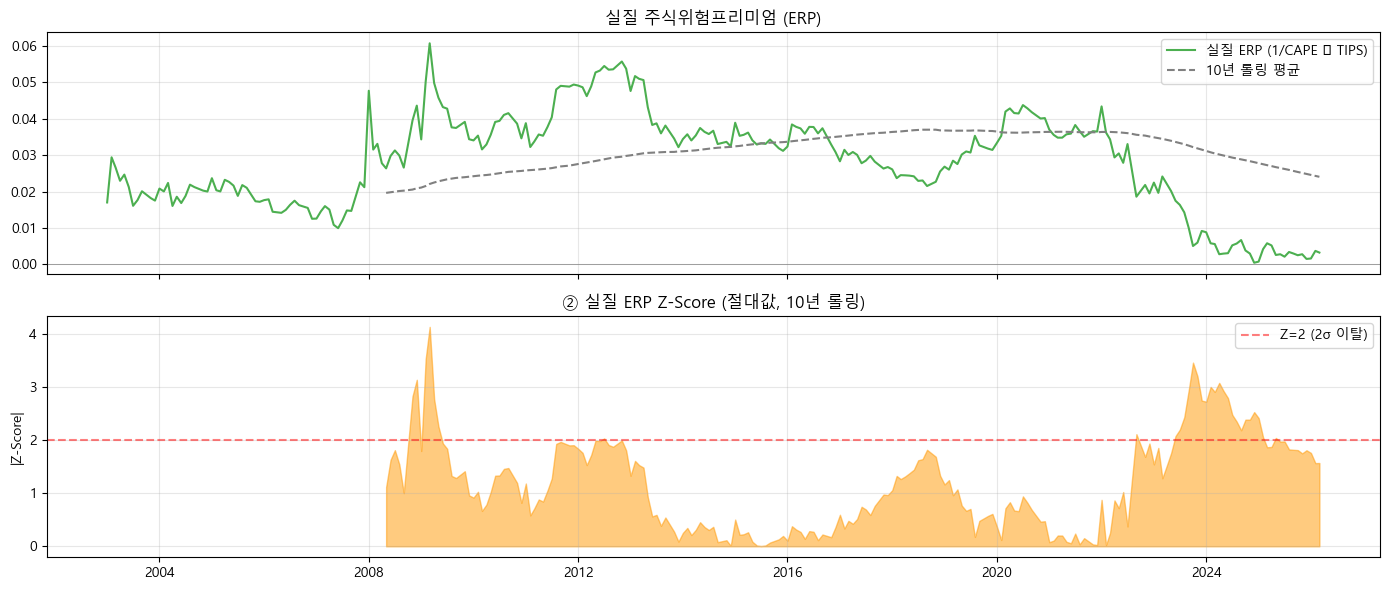

In [ ]:
# ── Cell 4: 변수 ② 실질 ERP 괴리 (10년 Z-Score) ──────────────────────────
# Shiller CAPE에서 실질이익수익률
if cape_available:
    cape_series = shiller['CAPE'].dropna()
else:
    # CAPE 없으면 P/E10 직접 계산 (10년 평균 이익)
    e10 = shiller['E'].rolling(120, min_periods=60).mean()
    cape_series = shiller['P'] / e10
    cape_series = cape_series.dropna()

real_earnings_yield = 1.0 / cape_series  # 실질이익수익률

# TIPS 실질금리 (월별, % → 소수)
tips_aligned = tips_monthly / 100.0

# 실질 ERP = 실질이익수익률 − TIPS 실질금리
erp_df = pd.DataFrame({
    'earnings_yield': real_earnings_yield,
    'tips_rate': tips_aligned,
}).dropna()
erp = erp_df['earnings_yield'] - erp_df['tips_rate']

# 10년(120개월) 롤링 Z-Score
erp_roll_mean = erp.rolling(120, min_periods=60).mean()
erp_roll_std  = erp.rolling(120, min_periods=60).std()
erp_zscore = ((erp - erp_roll_mean) / erp_roll_std).abs()  # 절대값: 양방향 괴리
erp_zscore = erp_zscore.dropna()
erp_zscore.name = 'erp_zscore'

print(f'변수 ② 실질 ERP Z-Score: {len(erp_zscore)}개월')
print(f'  기간: {erp_zscore.index[0].date()} ~ {erp_zscore.index[-1].date()}')
print(f'  평균: {erp_zscore.mean():.4f}  |  표준편차: {erp_zscore.std():.4f}')

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(erp.index, erp, label='실질 ERP (1/CAPE − TIPS)', color='#4CAF50')
axes[0].plot(erp_roll_mean.index, erp_roll_mean, label='10년 롤링 평균', color='gray', linestyle='--')
axes[0].legend()
axes[0].set_title('실질 주식위험프리미엄 (ERP)')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].grid(alpha=0.3)

axes[1].fill_between(erp_zscore.index, erp_zscore, 0, color='#FF9800', alpha=0.5)
axes[1].axhline(2, color='red', linestyle='--', alpha=0.5, label='Z=2 (2σ 이탈)')
axes[1].set_title('② 실질 ERP Z-Score (절대값, 10년 롤링)')
axes[1].set_ylabel('|Z-Score|')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 변수 ③ 섹터 동조화 (베타 제거 잔차 상관 + 크로스섹션 디스퍼전)
- 5섹터 × 5종목의 일별 수익률에서 SPY 시장 베타 제거 → 잔차 수익률
- 잔차 20일 롤링 페어와이즈 상관 → 전체 평균 = `residual_corr`
- 전 종목 일별 수익률의 횡단면 표준편차 → 20일 롤링 = `dispersion`
- residual_corr 높으면 → 개별 요인 무시, 묻지마 매매 (감정적)
- dispersion 낮으면 → 차별 없는 일괄 매매 (감정적)

25개 종목 + SPY 일별 종가 수집 중...
  ✓ SPY: 4546일
  ✓ AAPL: 4546일
  ✓ MSFT: 4546일
  ✓ NVDA: 4546일
  ✓ AVGO: 4171일
  ✓ CRM: 4546일
  ✓ JPM: 4546일
  ✓ BAC: 4546일
  ✓ WFC: 4546일
  ✓ GS: 4546일
  ✓ MS: 4546일
  ✓ XOM: 4546일
  ✓ CVX: 4546일
  ✓ COP: 4546일
  ✓ SLB: 4546일
  ✓ EOG: 4546일
  ✓ UNH: 4546일
  ✓ JNJ: 4546일
  ✓ LLY: 4546일
  ✓ PFE: 4546일
  ✓ ABT: 4546일
  ✓ CAT: 4546일
  ✓ HON: 4546일
  ✓ UNP: 4546일
  ✓ GE: 4546일
  ✓ RTX: 4546일

시장 베타 제거 중...

변수 ③-A 잔차 상관: 198개월
  기간: 2009-10-01 ~ 2026-03-01
  평균: 0.3245  |  표준편차: 0.0982
변수 ③-B 디스퍼전: 199개월
  기간: 2009-09-01 ~ 2026-03-01
  평균: 0.0132  |  표준편차: 0.0032


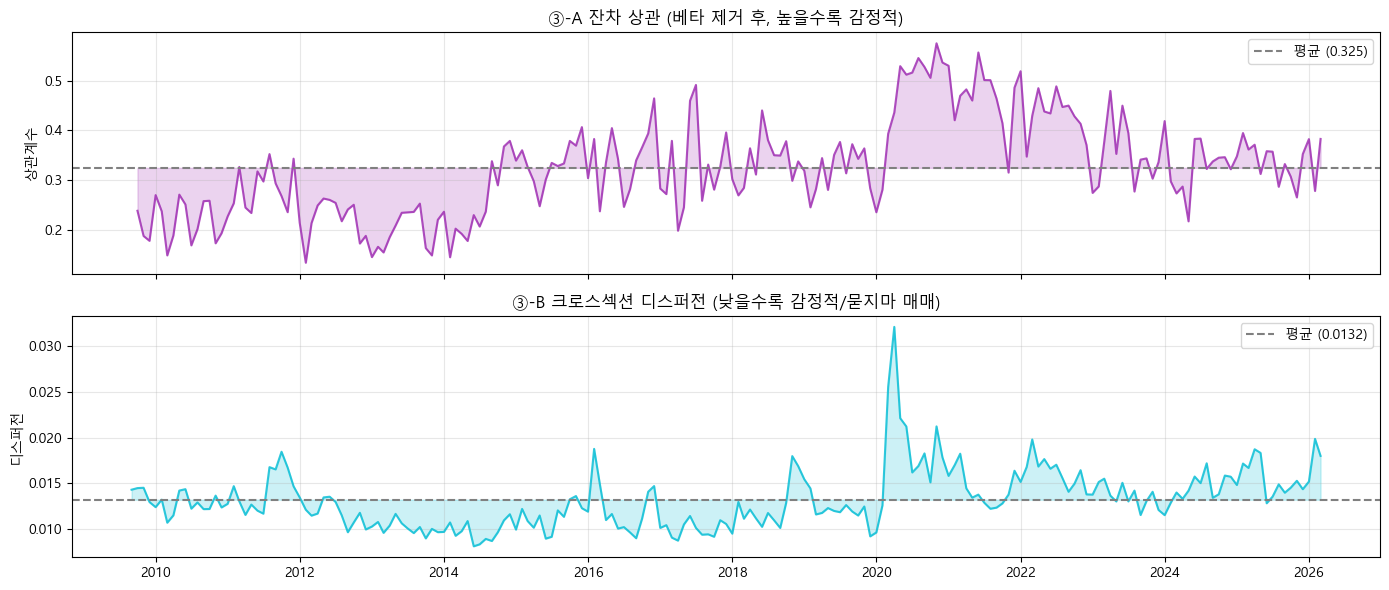

In [ ]:
# ── Cell 5: 변수 ③ 섹터 동조화 (잔차 상관 + 디스퍼전) ─────────────────────
from itertools import combinations

SECTOR_STOCKS = {
    'XLK': ['AAPL', 'MSFT', 'NVDA', 'AVGO', 'CRM'],
    'XLF': ['JPM', 'BAC', 'WFC', 'GS', 'MS'],
    'XLE': ['XOM', 'CVX', 'COP', 'SLB', 'EOG'],
    'XLV': ['UNH', 'JNJ', 'LLY', 'PFE', 'ABT'],
    'XLI': ['CAT', 'HON', 'UNP', 'GE', 'RTX'],
}
all_stocks = [s for stocks in SECTOR_STOCKS.values() for s in stocks]

print(f'{len(all_stocks)}개 종목 + SPY 일별 종가 수집 중...')
stock_frames = {}
start_date = str(datetime.date.today() - datetime.timedelta(days=365 * 18 + 30))

# SPY도 함께 수집 (베타 제거용)
for ticker in ['SPY'] + all_stocks:
    try:
        t = yf.Ticker(ticker)
        hist = t.history(start=start_date, auto_adjust=True)
        if len(hist) > 0:
            stock_frames[ticker] = hist['Close']
            print(f'  ✓ {ticker}: {len(hist)}일')
        else:
            print(f'  ✗ {ticker}: 데이터 없음')
    except Exception as e:
        print(f'  ✗ {ticker}: {e}')

stock_prices = pd.DataFrame(stock_frames)
stock_prices.index = pd.to_datetime(stock_prices.index)
if stock_prices.index.tz is not None:
    stock_prices.index = stock_prices.index.tz_localize(None)

# 일별 수익률
stock_returns = stock_prices.pct_change().dropna()
spy_ret = stock_returns['SPY']

# ── 베타 제거 잔차 수익률 ──
print('\n시장 베타 제거 중...')
residuals = pd.DataFrame(index=stock_returns.index)

for ticker in all_stocks:
    if ticker not in stock_returns.columns:
        continue
    ret = stock_returns[ticker]
    # 60일 롤링 베타
    cov_with_spy = ret.rolling(60, min_periods=30).cov(spy_ret)
    spy_var = spy_ret.rolling(60, min_periods=30).var()
    beta = cov_with_spy / spy_var
    residuals[ticker] = ret - beta * spy_ret

residuals = residuals.dropna(how='all')

# ── 잔차 20일 롤링 페어와이즈 상관 → 전체 평균 ──
def sector_residual_corr(resid_df, sector_dict, window=20):
    """섹터별 잔차 20일 롤링 페어와이즈 상관 → 전체 평균."""
    sector_corrs = []
    for sector, stocks in sector_dict.items():
        available = [s for s in stocks if s in resid_df.columns]
        if len(available) < 2:
            continue
        pairs = list(combinations(available, 2))
        pair_corrs = []
        for s1, s2 in pairs:
            rc = resid_df[s1].rolling(window).corr(resid_df[s2])
            pair_corrs.append(rc)
        sector_avg = pd.concat(pair_corrs, axis=1).mean(axis=1)
        sector_corrs.append(sector_avg)
    return pd.concat(sector_corrs, axis=1).mean(axis=1)

daily_resid_corr = sector_residual_corr(residuals, SECTOR_STOCKS).dropna()
residual_corr_monthly = daily_resid_corr.resample('MS').mean().dropna()
residual_corr_monthly.name = 'residual_corr'

# ── 크로스섹션 디스퍼전: 전 종목 일별 수익률의 횡단면 표준편차 ──
available_stocks = [s for s in all_stocks if s in stock_returns.columns]
cross_section_std = stock_returns[available_stocks].std(axis=1)  # 매일 25종목의 수익률 표준편차
dispersion_daily = cross_section_std.rolling(20).mean().dropna()
dispersion_monthly = dispersion_daily.resample('MS').mean().dropna()
dispersion_monthly.name = 'dispersion'

print(f'\n변수 ③-A 잔차 상관: {len(residual_corr_monthly)}개월')
print(f'  기간: {residual_corr_monthly.index[0].date()} ~ {residual_corr_monthly.index[-1].date()}')
print(f'  평균: {residual_corr_monthly.mean():.4f}  |  표준편차: {residual_corr_monthly.std():.4f}')
print(f'변수 ③-B 디스퍼전: {len(dispersion_monthly)}개월')
print(f'  기간: {dispersion_monthly.index[0].date()} ~ {dispersion_monthly.index[-1].date()}')
print(f'  평균: {dispersion_monthly.mean():.4f}  |  표준편차: {dispersion_monthly.std():.4f}')

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(residual_corr_monthly.index, residual_corr_monthly, color='#9C27B0', alpha=0.8)
axes[0].fill_between(residual_corr_monthly.index, residual_corr_monthly, residual_corr_monthly.mean(),
                alpha=0.2, color='#9C27B0')
axes[0].axhline(residual_corr_monthly.mean(), color='gray', linestyle='--',
               label=f'평균 ({residual_corr_monthly.mean():.3f})')
axes[0].set_title('③-A 잔차 상관 (베타 제거 후, 높을수록 감정적)')
axes[0].set_ylabel('상관계수')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(dispersion_monthly.index, dispersion_monthly, color='#00BCD4', alpha=0.8)
axes[1].fill_between(dispersion_monthly.index, dispersion_monthly, dispersion_monthly.mean(),
                alpha=0.2, color='#00BCD4')
axes[1].axhline(dispersion_monthly.mean(), color='gray', linestyle='--',
               label=f'평균 ({dispersion_monthly.mean():.4f})')
axes[1].set_title('③-B 크로스섹션 디스퍼전 (낮을수록 감정적/묻지마 매매)')
axes[1].set_ylabel('디스퍼전')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Amihud 비유동성: 5개 대형주 OHLCV 수집 중...
  ✓ AAPL: 4546일
  ✓ MSFT: 4546일
  ✓ AMZN: 4546일
  ✓ GOOGL: 4546일
  ✓ META: 3469일

변수 ④ Amihud 비유동성 (로그, 윈저라이징): 217개월
  기간: 2008-03-01 ~ 2026-03-01
  평균: -26.3138  |  표준편차: 0.7832


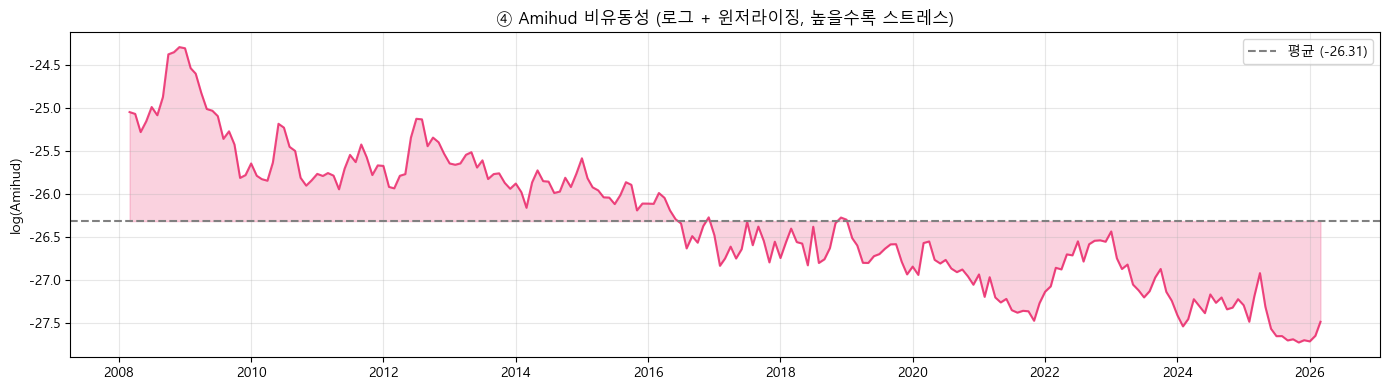

In [ ]:
# ── Cell 6: 변수 ④ Amihud 비유동성 (개선: open-to-close + 로그 + 윈저라이징) ─
AMIHUD_STOCKS = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META']

print(f'Amihud 비유동성: {len(AMIHUD_STOCKS)}개 대형주 OHLCV 수집 중...')
amihud_frames = {}
for ticker in AMIHUD_STOCKS:
    try:
        t = yf.Ticker(ticker)
        hist = t.history(start=start_date, auto_adjust=True)
        if len(hist) > 0:
            amihud_frames[ticker] = hist[['Open', 'Close', 'Volume']]
            print(f'  ✓ {ticker}: {len(hist)}일')
        else:
            print(f'  ✗ {ticker}: 데이터 없음')
    except Exception as e:
        print(f'  ✗ {ticker}: {e}')

# 종목별 Amihud = |log(close/open)| / (close × volume)
amihud_per_stock = []
for ticker, df_t in amihud_frames.items():
    oc_ret = np.log(df_t['Close'] / df_t['Open']).abs()  # open-to-close 절대 로그수익률
    dollar_vol = df_t['Close'] * df_t['Volume']
    amihud_t = oc_ret / dollar_vol.replace(0, np.nan)
    amihud_per_stock.append(amihud_t)

# 5종목 평균 → 20일 롤링 평균
amihud_avg = pd.concat(amihud_per_stock, axis=1).mean(axis=1).dropna()
amihud_rolling = amihud_avg.rolling(20).mean().dropna()

# 로그 변환
log_amihud = np.log(amihud_rolling + 1e-15)

# 1/99 퍼센타일 윈저라이징
q01 = log_amihud.quantile(0.01)
q99 = log_amihud.quantile(0.99)
log_amihud_w = log_amihud.clip(q01, q99)

# 타임존 제거 (yfinance가 US/Eastern 타임존을 붙이는 경우 대응)
if hasattr(log_amihud_w.index, 'tz') and log_amihud_w.index.tz is not None:
    log_amihud_w.index = log_amihud_w.index.tz_localize(None)

# 월별 리샘플링
amihud_monthly = log_amihud_w.resample('MS').mean().dropna()
amihud_monthly.name = 'amihud'

print(f'\n변수 ④ Amihud 비유동성 (로그, 윈저라이징): {len(amihud_monthly)}개월')
print(f'  기간: {amihud_monthly.index[0].date()} ~ {amihud_monthly.index[-1].date()}')
print(f'  평균: {amihud_monthly.mean():.4f}  |  표준편차: {amihud_monthly.std():.4f}')

# 시각화
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(amihud_monthly.index, amihud_monthly, color='#E91E63', alpha=0.8)
ax.fill_between(amihud_monthly.index, amihud_monthly, amihud_monthly.mean(), alpha=0.2, color='#E91E63')
ax.axhline(amihud_monthly.mean(), color='gray', linestyle='--', label=f'평균 ({amihud_monthly.mean():.2f})')
ax.set_title('④ Amihud 비유동성 (로그 + 윈저라이징, 높을수록 스트레스)')
ax.set_ylabel('log(Amihud)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

변수 ⑤ VIX 기간구조 (VIX/VIX3M): 220개월
  기간: 2007-12-01 ~ 2026-03-01
  평균: 0.9132  |  표준편차: 0.0783
  백워데이션(>1.0) 비율: 11.8%


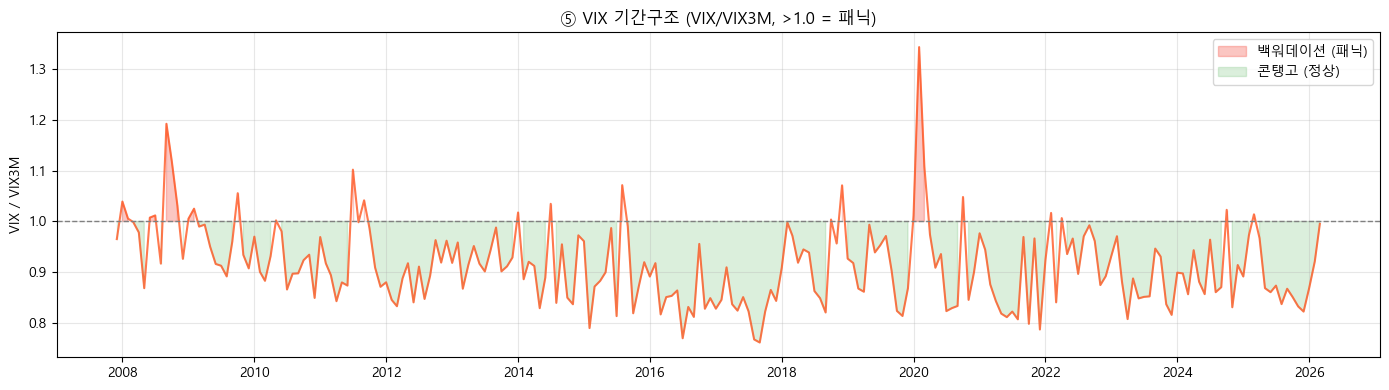

In [ ]:
# ── Cell 7: 변수 ⑤ VIX 기간구조 ────────────────────────────────────────────
# VIX / VIX3M 비율
# > 1.0 = 백워데이션 (단기 공포 > 장기) = 패닉 신호
# < 1.0 = 콘탱고 (정상)

vix_term_df = pd.DataFrame({
    'vix': vix_monthly,
    'vix3m': vix3m_monthly,
}).dropna()

vix_term = vix_term_df['vix'] / vix_term_df['vix3m']
vix_term = vix_term.dropna()
vix_term.name = 'vix_term'

print(f'변수 ⑤ VIX 기간구조 (VIX/VIX3M): {len(vix_term)}개월')
print(f'  기간: {vix_term.index[0].date()} ~ {vix_term.index[-1].date()}')
print(f'  평균: {vix_term.mean():.4f}  |  표준편차: {vix_term.std():.4f}')
print(f'  백워데이션(>1.0) 비율: {(vix_term > 1.0).mean()*100:.1f}%')

# 시각화
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(vix_term.index, vix_term, color='#FF5722', alpha=0.8)
ax.fill_between(vix_term.index, vix_term, 1.0,
                where=vix_term > 1.0, color='#F44336', alpha=0.3, label='백워데이션 (패닉)')
ax.fill_between(vix_term.index, vix_term, 1.0,
                where=vix_term <= 1.0, color='#4CAF50', alpha=0.2, label='콘탱고 (정상)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_title('⑤ VIX 기간구조 (VIX/VIX3M, >1.0 = 패닉)')
ax.set_ylabel('VIX / VIX3M')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

변수 ⑥ 하이일드 스프레드: 352개월
  평균: 5.2126  |  표준편차: 2.5030


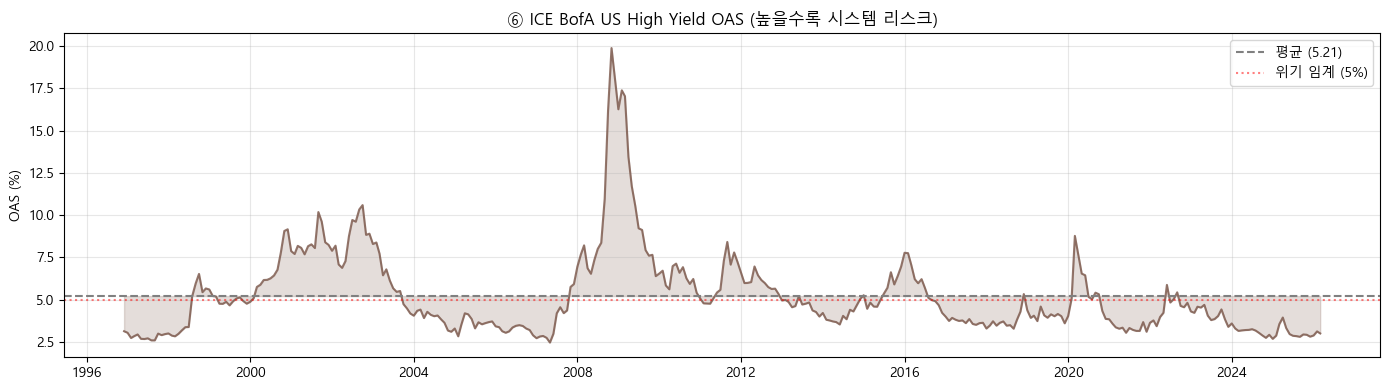

In [ ]:
# ── Cell 8: 변수 ⑥ 하이일드 스프레드 ──────────────────────────────────────

# ⑥ 하이일드 OAS (이미 Cell 3에서 수집)
hy_spread = hy_monthly.copy()
hy_spread.name = 'hy_spread'

print(f'변수 ⑥ 하이일드 스프레드: {len(hy_spread)}개월')
print(f'  평균: {hy_spread.mean():.4f}  |  표준편차: {hy_spread.std():.4f}')

# 시각화
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hy_spread.index, hy_spread, color='#795548', alpha=0.8)
ax.fill_between(hy_spread.index, hy_spread, hy_spread.mean(), alpha=0.2, color='#795548')
ax.axhline(hy_spread.mean(), color='gray', linestyle='--',
           label=f'평균 ({hy_spread.mean():.2f})')
ax.axhline(5.0, color='red', linestyle=':', alpha=0.5, label='위기 임계 (5%)')
ax.set_title('⑥ ICE BofA US High Yield OAS (높을수록 시스템 리스크)')
ax.set_ylabel('OAS (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

변수 ⑦ 실현 변동성: 199개월
  평균: 0.1466  |  표준편차: 0.0833

각 시리즈 마지막 날짜:
  fundamental_gap     : 2026-03-01 00:00:00  (1699개월)
  erp_zscore          : 2026-03-01 00:00:00  (200개월)
  residual_corr       : 2026-03-01 00:00:00  (198개월)
  dispersion          : 2026-03-01 00:00:00  (199개월)
  amihud              : 2026-03-01 00:00:00  (217개월)
  vix_term            : 2026-03-01 00:00:00  (220개월)
  hy_spread           : 2026-03-01 00:00:00  (352개월)
  realized_vol        : 2026-03-01 00:00:00  (199개월)

윈저라이징 전: (184, 8)
  fundamental_gap: 4개 값 클리핑 [-1.9528, 0.5125]
  erp_zscore: 4개 값 클리핑 [0.0144, 3.1043]
  residual_corr: 4개 값 클리핑 [0.1449, 0.5472]
  dispersion: 4개 값 클리핑 [0.0086, 0.0227]
  amihud: 4개 값 클리핑 [-27.7017, -25.1757]
  vix_term: 4개 값 클리핑 [0.7694, 1.1031]
  hy_spread: 4개 값 클리핑 [2.7898, 7.8954]
  realized_vol: 4개 값 클리핑 [0.0588, 0.4875]
윈저라이징 후: (184, 8)

피처 DataFrame: (184, 8) | 2009-11-01 ~ 2026-03-01

기술통계:
       fundamental_gap  erp_zscore  residual_corr  dispersion    amihud  \
count         

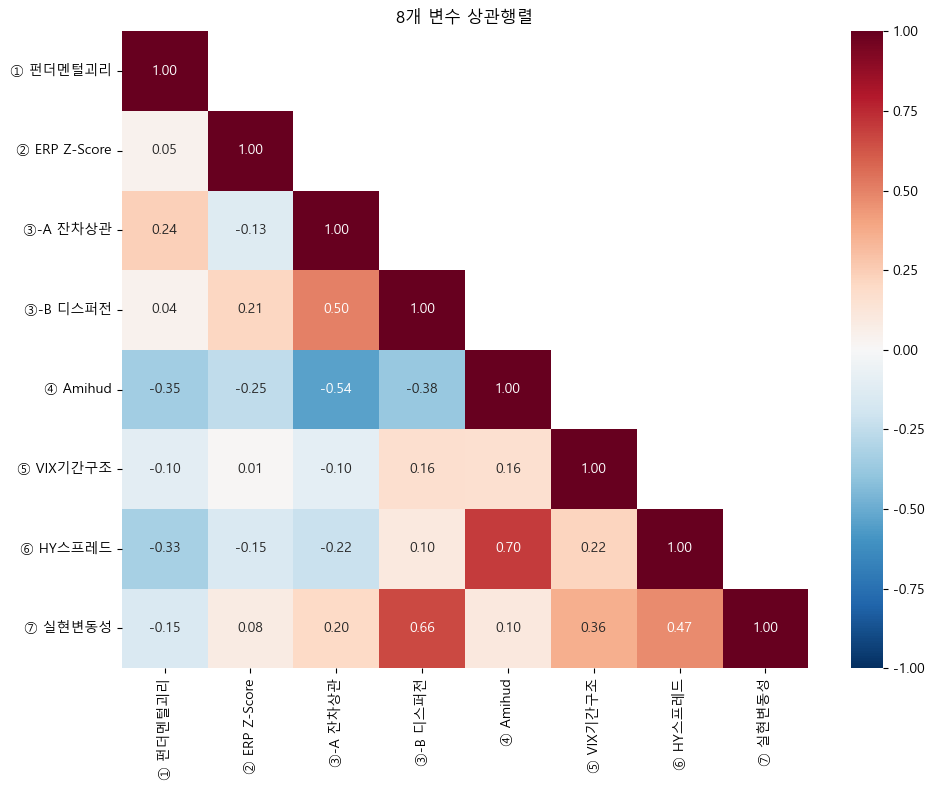

In [ ]:
# ── Cell 9: 피처 병합 + 윈저라이징 + 상관분석 ──────────────────────────────
def strip_tz(s):
    s = s.copy()
    if hasattr(s.index, 'tz') and s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    return s

# ── 변수 ⑦ S&P 500 실현 변동성 (20일 롤링 연율화) ──
spy_ret_clean = strip_tz(spy_ret)
realized_vol_daily = spy_ret_clean.rolling(20).std() * np.sqrt(252)  # 연율화
realized_vol_monthly = realized_vol_daily.resample('MS').mean().dropna()
realized_vol_monthly.name = 'realized_vol'
print(f'변수 ⑦ 실현 변동성: {len(realized_vol_monthly)}개월')
print(f'  평균: {realized_vol_monthly.mean():.4f}  |  표준편차: {realized_vol_monthly.std():.4f}')

all_series = {
    'fundamental_gap': fundamental_gap,
    'erp_zscore':      erp_zscore,
    'residual_corr':   residual_corr_monthly,
    'dispersion':      dispersion_monthly,
    'amihud':          amihud_monthly,
    'vix_term':        vix_term,
    'hy_spread':       hy_spread,
    'realized_vol':    realized_vol_monthly,
}

print('\n각 시리즈 마지막 날짜:')
for name, s in all_series.items():
    last = s.dropna().index[-1]
    print(f'  {name:20s}: {last}  ({len(s.dropna())}개월)')

features = pd.DataFrame({k: strip_tz(v) for k, v in all_series.items()})
features = features.dropna()

# ── 윈저라이징 (1/99 퍼센타일) — 극단값 영향 제한 ──
print(f'\n윈저라이징 전: {features.shape}')
for col in FEATURE_NAMES:
    q01 = features[col].quantile(0.01)
    q99 = features[col].quantile(0.99)
    n_clipped = ((features[col] < q01) | (features[col] > q99)).sum()
    features[col] = features[col].clip(q01, q99)
    if n_clipped > 0:
        print(f'  {col}: {n_clipped}개 값 클리핑 [{q01:.4f}, {q99:.4f}]')
print(f'윈저라이징 후: {features.shape}')

print(f'\n피처 DataFrame: {features.shape} | {features.index[0].date()} ~ {features.index[-1].date()}')
print(f'\n기술통계:')
print(features.describe().round(4))

# 상관 히트맵
fig, ax = plt.subplots(figsize=(10, 8))
corr = features.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
feature_display = ['① 펀더멘털괴리', '② ERP Z-Score', '③-A 잔차상관',
                   '③-B 디스퍼전', '④ Amihud', '⑤ VIX기간구조', '⑥ HY스프레드',
                   '⑦ 실현변동성']
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    mask=mask, ax=ax, vmin=-1, vmax=1,
    xticklabels=feature_display,
    yticklabels=feature_display,
)
ax.set_title('8개 변수 상관행렬')
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 10: HMM 학습 (N_STATES=4) ───────────────────────────────────────
X = features[FEATURE_NAMES].values
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# GaussianHMM: full 공분산 시도 → diag 폴백
for cov_type in ('full', 'diag'):
    try:
        model = GaussianHMM(
            n_components=N_STATES,
            covariance_type=cov_type,
            n_iter=200,
            random_state=42,
        )
        model.fit(X_scaled)
        print(f'HMM 학습 완료 (covariance: {cov_type}, scaler: RobustScaler)')
        break
    except (ValueError, np.linalg.LinAlgError):
        if cov_type == 'diag':
            raise

# Viterbi 상태 시퀀스
states = model.predict(X_scaled)
features['state'] = states

ll = model.score(X_scaled)
print(f'Log-likelihood: {ll:.2f}')
print(f'Per-sample LL: {ll / len(X_scaled):.4f}')
print(f'학습 데이터: {len(X_scaled)}개월, 피처: {X_scaled.shape[1]}개')
print(f'\n상태별 관측 수:')
print(pd.Series(states).value_counts().sort_index())

HMM 학습 완료 (covariance: full, scaler: RobustScaler)
Log-likelihood: -978.73
Per-sample LL: -5.3192
학습 데이터: 184개월, 피처: 8개

상태별 관측 수:
0    95
1    10
2    57
3    22
Name: count, dtype: int64


noise_score v2 가중치:
  펀더멘털괴리      : 0.5
  ERP Z-Score : 0.3
  잔차상관        : 1.0
  디스퍼전        : 제거
  Amihud      : 0.5
  VIX기간구조     : 2.0
  HY스프레드      : 1.5
  실현변동성       : 2.0

HMM 상태 → 국면 매핑 (noise_score 오름차순):
  state 3 → 🧠 펀더멘털 반영  (noise_score: -1.419)
    펀더멘털괴리: 0.1297 (scaled: 0.3504)
    ERP Z-Score: 2.3473 (scaled: 0.9887)
    잔차상관: 0.3249 (scaled: 0.0044)
    디스퍼전: 0.0137 (scaled: 0.2334)
    Amihud: -27.3255 (scaled: -0.7030)
    VIX기간구조: 0.8673 (scaled: -0.3073)
    HY스프레드: 3.4266 (scaled: -0.4734)
    실현변동성: 0.1109 (scaled: -0.1097)
  state 0 → ⚖️ 펀더멘털 약반영  (noise_score: -0.230)
    펀더멘털괴리: 0.0574 (scaled: 0.0062)
    ERP Z-Score: 0.9677 (scaled: 0.0120)
    잔차상관: 0.2932 (scaled: -0.2349)
    디스퍼전: 0.0115 (scaled: -0.3283)
    Amihud: -26.2494 (scaled: 0.2773)
    VIX기간구조: 0.8934 (scaled: -0.0356)
    HY스프레드: 4.4593 (scaled: 0.0995)
    실현변동성: 0.1109 (scaled: -0.1092)
  state 2 → 🌊 센티멘트 약반영  (noise_score: 4.018)
    펀더멘털괴리: -0.0072 (scaled: -0.3011)
    ERP Z-Score: 0.8

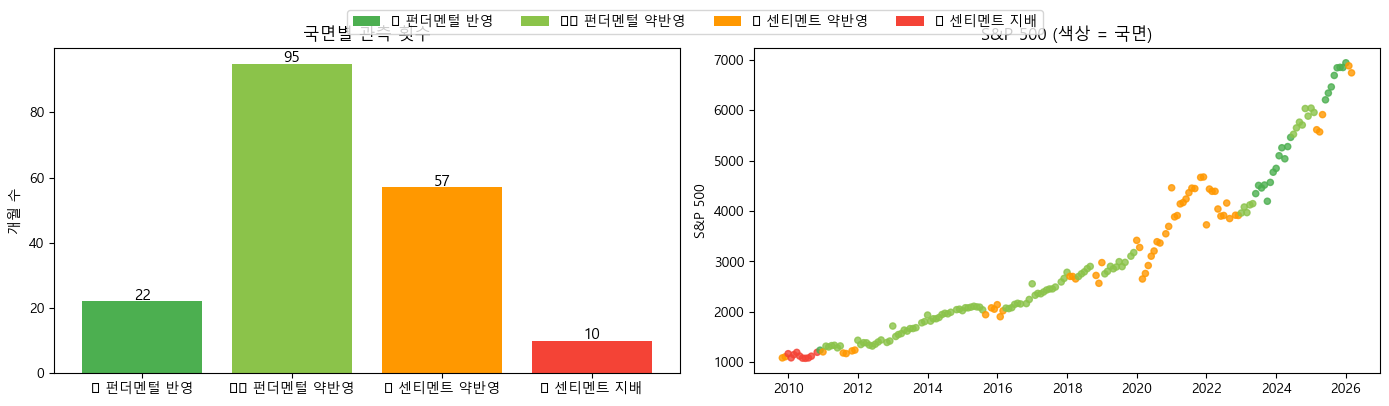


국면 분포:
  🧠 펀더멘털 반영: 22개월 (12.0%)
  ⚖️ 펀더멘털 약반영: 95개월 (51.6%)
  🌊 센티멘트 약반영: 57개월 (31.0%)
  🔥 센티멘트 지배: 10개월 (5.4%)


In [ ]:
# ── Cell 11: noise_score 기반 상태 매핑 + 시각화 ───────────────────────────
# ── noise_score v2: 상관 기반 가중치 + realized_vol ──
# 진단 (D)에서 도출한 각 변수와 S&P 500 월간수익률의 상관 방향/크기를 반영
# noise↑ = 수익률과 음의 상관인 변수에 양의 가중치
# 
# 변경점 (v1 → v2):
#   1. fundamental_gap: |abs| → 부호 유지 (+과열 noise, -공포 noise → 양쪽 noise)
#      BUT corr=+0.11이라 양수일 때 오히려 수익률 상승 → 가중치 대폭 축소 (0.5)
#   2. erp_zscore: |abs| 유지하되 가중치 축소 (corr≈0, 거의 무관)  → 0.3
#   3. residual_corr: + → noise (corr=-0.03, 약한 음의 상관) → 1.0 유지
#   4. dispersion: 방향 제거 (corr=-0.11, 높을수록 수익률 하락이지만
#      기존 "-"부호가 왜곡 유발) → 가중치 0 (제거)
#   5. amihud: + → noise (corr=-0.04) → 0.5로 축소
#   6. vix_term: + → noise (corr=-0.22, 가장 강한 상관) → 2.0으로 상향
#   7. hy_spread: + → noise (corr=-0.13) → 1.5
#   8. realized_vol: + → noise (변동성 높을수록 센티멘트) → 2.0 (핵심 보조변수)

def compute_noise_score(means):
    """피처 순서: fundamental_gap, erp_zscore, residual_corr,
              dispersion, amihud, vix_term, hy_spread, realized_vol
    상관 기반 가중치: vix_term(2.0), realized_vol(2.0), hy_spread(1.5),
                     residual_corr(1.0), amihud(0.5), fund_gap(0.5), erp_z(0.3)
    dispersion: 제거 (방향 왜곡 유발)"""
    return (
        0.5 * np.abs(means[:, 0])   # fundamental_gap (축소)
      + 0.3 * np.abs(means[:, 1])   # erp_zscore (축소)
      + 1.0 * means[:, 2]           # residual_corr
      # dispersion 제거 (가중치 0)
      + 0.5 * means[:, 4]           # amihud (축소)
      + 2.0 * means[:, 5]           # vix_term (상향, 가장 유의미)
      + 1.5 * means[:, 6]           # hy_spread (상향)
      + 2.0 * means[:, 7]           # realized_vol (신규, 핵심)
    )

noise_scores = compute_noise_score(model.means_)
sorted_states = np.argsort(noise_scores)
state_to_phase = {int(sid): RANK_TO_PHASE[rank] for rank, sid in enumerate(sorted_states)}
features['phase'] = [state_to_phase[s] for s in features['state']]

feature_labels = ['펀더멘털괴리', 'ERP Z-Score', '잔차상관', '디스퍼전',
                  'Amihud', 'VIX기간구조', 'HY스프레드', '실현변동성']
print('noise_score v2 가중치:')
weights = [0.5, 0.3, 1.0, 0.0, 0.5, 2.0, 1.5, 2.0]
for fl, w in zip(feature_labels, weights):
    if w > 0:
        print(f'  {fl:12s}: {w:.1f}')
    else:
        print(f'  {fl:12s}: 제거')

print('\nHMM 상태 → 국면 매핑 (noise_score 오름차순):')
for rank, sid in enumerate(sorted_states):
    ph = RANK_TO_PHASE[rank]
    ns = noise_scores[sid]
    means_orig = scaler.inverse_transform(model.means_[[sid]])[0]
    print(f'  state {sid} → {PHASE_NAMES[ph]}  (noise_score: {ns:.3f})')
    for i, fl in enumerate(feature_labels):
        print(f'    {fl}: {means_orig[i]:.4f} (scaled: {model.means_[sid, i]:.4f})')

from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = features['phase'].value_counts().sort_index()
colors = [PHASE_COLORS[i] for i in counts.index]
axes[0].bar([PHASE_NAMES[i] for i in counts.index], counts.values, color=colors)
axes[0].set_title('국면별 관측 횟수')
axes[0].set_ylabel('개월 수')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=11)

sp_sorted = shiller['P'].sort_index()
sp_aligned = sp_sorted.reindex(features.index, method='ffill')
axes[1].scatter(features.index, sp_aligned,
               c=[PHASE_COLORS[p] for p in features['phase']], s=20, alpha=0.8)
axes[1].set_title('S&P 500 (색상 = 국면)')
axes[1].set_ylabel('S&P 500')

legend_elements = [Patch(facecolor=PHASE_COLORS[k], label=PHASE_NAMES[k]) for k in range(4)]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

print('\n국면 분포:')
for ph, cnt in counts.items():
    print(f'  {PHASE_NAMES[ph]}: {cnt}개월 ({cnt/len(features)*100:.1f}%)')

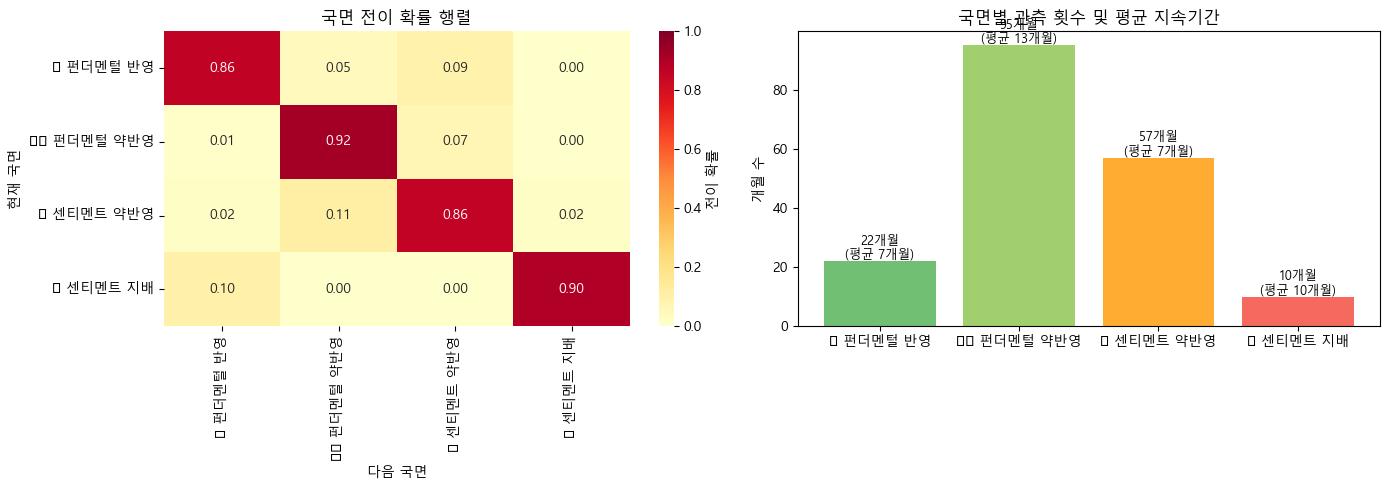

전이 확률 요약:
  🧠 펀더멘털 반영: 자기전이 86.3% → 평균 지속 7.3개월
  ⚖️ 펀더멘털 약반영: 자기전이 92.2% → 평균 지속 12.8개월
  🌊 센티멘트 약반영: 자기전이 85.6% → 평균 지속 6.9개월
  🔥 센티멘트 지배: 자기전이 90.0% → 평균 지속 10.0개월


In [ ]:
# ── Cell 12: 전이확률 행렬 + 지속기간 ──────────────────────────────────────
trans_mat = model.transmat_

# 국면 순서로 재배열
phase_order = []
for ph in range(4):
    for s in range(4):
        if state_to_phase[s] == ph:
            phase_order.append(s)
            break

reordered = trans_mat[np.ix_(phase_order, phase_order)]
reordered_labels = [PHASE_NAMES[state_to_phase[s]] for s in phase_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [좌] 전이 확률 히트맵
sns.heatmap(
    reordered, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=reordered_labels, yticklabels=reordered_labels,
    ax=axes[0], vmin=0, vmax=1, cbar_kws={'label': '전이 확률'}
)
axes[0].set_title('국면 전이 확률 행렬')
axes[0].set_xlabel('다음 국면')
axes[0].set_ylabel('현재 국면')

# [우] 국면별 관측 수 + 평균 지속기간
counts_ordered = [int((features['phase'] == ph).sum()) for ph in range(4)]
durations = [1 / (1 - reordered[i, i]) if reordered[i, i] < 1 else float('inf') for i in range(4)]

bars = axes[1].bar(
    [PHASE_NAMES[ph] for ph in range(4)], counts_ordered,
    color=[PHASE_COLORS[ph] for ph in range(4)], alpha=0.8
)
axes[1].set_title('국면별 관측 횟수 및 평균 지속기간')
axes[1].set_ylabel('개월 수')
for i, (v, d) in enumerate(zip(counts_ordered, durations)):
    axes[1].text(i, v + 0.5, f'{v}개월\n(평균 {d:.0f}개월)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 전이 확률 요약
print('전이 확률 요약:')
for i, ph in enumerate(range(4)):
    s = phase_order[i]
    self_prob = trans_mat[s, s]
    print(f'  {PHASE_NAMES[ph]}: 자기전이 {self_prob:.1%} → 평균 지속 {1/(1-self_prob):.1f}개월')

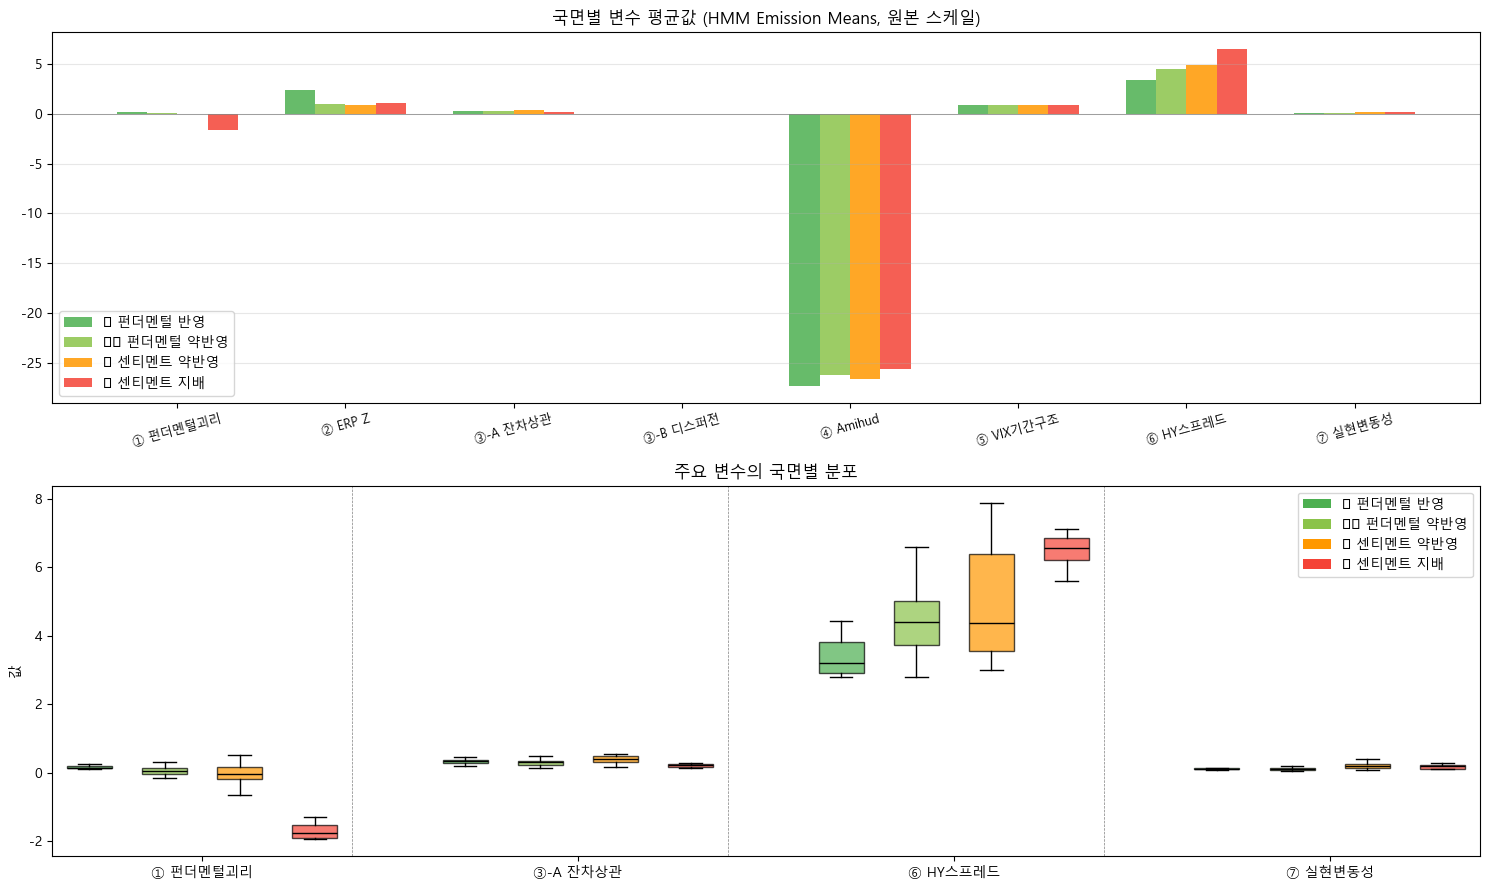


국면별 주요 변수 평균:
                         펀더멘털    ERP Z     잔차상관     디스퍼전   Amihud    VIX기간   HY OAS    실현Vol
--------------------------------------------------------------------------------------------
🧠 펀더멘털 반영               0.130    2.347   0.3249   0.0137   -27.33    0.867     3.43    0.111
⚖️ 펀더멘털 약반영             0.057    0.968   0.2932   0.0115   -26.25    0.893     4.46    0.111
🌊 센티멘트 약반영             -0.007    0.845   0.3921   0.0158   -26.66    0.926     4.94    0.204
🔥 센티멘트 지배              -1.654    1.122   0.2165   0.0127   -25.60    0.926     6.48    0.176


In [ ]:
# ── Cell 13: 발산 분포 분석 (국면별 변수 특성) ──────────────────────────────
means_reordered = scaler.inverse_transform(model.means_[phase_order])
feature_display = ['① 펀더멘털괴리', '② ERP Z', '③-A 잔차상관', '③-B 디스퍼전',
                   '④ Amihud', '⑤ VIX기간구조', '⑥ HY스프레드', '⑦ 실현변동성']

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

x = np.arange(len(FEATURE_NAMES))
width = 0.18
for i, ph in enumerate(range(4)):
    axes[0].bar(x + i * width - 1.5 * width, means_reordered[i], width,
                label=PHASE_NAMES[ph], color=PHASE_COLORS[ph], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(feature_display, fontsize=9, rotation=15)
axes[0].set_title('국면별 변수 평균값 (HMM Emission Means, 원본 스케일)')
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)

key_features = ['fundamental_gap', 'residual_corr', 'hy_spread', 'realized_vol']
key_labels = ['① 펀더멘털괴리', '③-A 잔차상관', '⑥ HY스프레드', '⑦ 실현변동성']

for idx, (feat, label) in enumerate(zip(key_features, key_labels)):
    for ph in range(4):
        mask = features['phase'] == ph
        vals = features.loc[mask, feat].values
        pos = idx * 5 + ph
        axes[1].boxplot(vals, positions=[pos], widths=0.6, patch_artist=True,
                        boxprops=dict(facecolor=PHASE_COLORS[ph], alpha=0.7),
                        medianprops=dict(color='black'), showfliers=False)
    if idx < len(key_features) - 1:
        axes[1].axvline(idx * 5 + 3.5, color='gray', linewidth=0.5, linestyle='--')

axes[1].set_xticks([1.5, 6.5, 11.5, 16.5])
axes[1].set_xticklabels(key_labels)
axes[1].set_title('주요 변수의 국면별 분포')
axes[1].set_ylabel('값')

legend_elements = [Patch(facecolor=PHASE_COLORS[k], label=PHASE_NAMES[k]) for k in range(4)]
axes[1].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print('\n국면별 주요 변수 평균:')
header = f'{"":20s} {"펀더멘털":>8s} {"ERP Z":>8s} {"잔차상관":>8s} {"디스퍼전":>8s} {"Amihud":>8s} {"VIX기간":>8s} {"HY OAS":>8s} {"실현Vol":>8s}'
print(header)
print('-' * len(header))
for i, ph in enumerate(range(4)):
    m = means_reordered[i]
    print(f'{PHASE_NAMES[ph]:20s} {m[0]:8.3f} {m[1]:8.3f} {m[2]:8.4f} {m[3]:8.4f} {m[4]:8.2f} {m[5]:8.3f} {m[6]:8.2f} {m[7]:8.3f}')

In [ ]:
# ── Cell 14: 일별 국면 예측 ────────────────────────────────────────────────
# 월별 학습 모델 + 일별 피처 → 오늘 기준 국면 확률
import datetime as _dt
from itertools import combinations as _combinations

today = pd.Timestamp(_dt.date.today())
print(f'일별 국면 예측 — 기준일: {today.strftime("%Y-%m-%d")}')
print('=' * 60)

# ── ① fundamental_gap: 월별 → forward-fill (마지막 값) ──
fg_val = features['fundamental_gap'].iloc[-1]

# ── ② erp_zscore: 월별 → forward-fill (마지막 값) ──
ez_val = features['erp_zscore'].iloc[-1]

# ── ③-A residual_corr: 최근 20 영업일 잔차 페어와이즈 상관 평균 ──
recent_resid = residuals.iloc[-20:]
pair_corrs = []
for sector, stocks in SECTOR_STOCKS.items():
    avail = [s for s in stocks if s in recent_resid.columns]
    if len(avail) < 2:
        continue
    for s1, s2 in _combinations(avail, 2):
        c = recent_resid[s1].corr(recent_resid[s2])
        pair_corrs.append(c)
rc_val = float(np.mean(pair_corrs)) if pair_corrs else residual_corr_monthly.iloc[-1]

# ── ③-B dispersion: 최근 20 영업일 횡단면 std 평균 ──
recent_ret = stock_returns[available_stocks].iloc[-20:]
disp_val = float(recent_ret.std(axis=1).mean())

# ── ④ amihud: 최근 20 영업일 → log → winsorize ──
amihud_daily_vals = []
for ticker, df_t in amihud_frames.items():
    recent_t = df_t.iloc[-20:]
    oc_ret = np.log(recent_t['Close'] / recent_t['Open']).abs()
    dollar_vol = recent_t['Close'] * recent_t['Volume']
    ami_t = oc_ret / dollar_vol.replace(0, np.nan)
    amihud_daily_vals.append(ami_t)
amihud_recent = pd.concat(amihud_daily_vals, axis=1).mean(axis=1).dropna()
log_ami = np.log(amihud_recent.mean() + 1e-15)
ami_val = float(np.clip(log_ami, q01, q99))

# ── ⑤ vix_term: 최신 일별 VIX / VIX3M ──
latest_vix = df_vix['vix'].dropna().iloc[-1]
latest_vix3m = df_vix3m['vix3m'].dropna().iloc[-1]
vt_val = float(latest_vix / latest_vix3m)

# ── ⑥ hy_spread: 최신 일별 값 ──
hy_val = float(df_hy['hy_spread'].dropna().iloc[-1])

# ── ⑦ realized_vol: 최근 20 영업일 SPY 실현 변동성 (연율화) ──
spy_ret_recent = spy_ret.iloc[-20:]
rv_val = float(spy_ret_recent.std() * np.sqrt(252))

# ── 8개 피처 → 예측 ──
daily_features = np.array([[fg_val, ez_val, rc_val, disp_val, ami_val, vt_val, hy_val, rv_val]])
daily_scaled = scaler.transform(daily_features)
daily_proba_raw = model.predict_proba(daily_scaled)[0]

proba_by_phase = {state_to_phase[i]: float(p) for i, p in enumerate(daily_proba_raw)}
pred_phase = max(proba_by_phase, key=proba_by_phase.get)

# ── 결과 출력 ──
print(f'\n  현재 국면: {PHASE_NAMES[pred_phase]}  (확률 {proba_by_phase[pred_phase]*100:.0f}%)')

print()
print('  국면별 확률:')
for ph in range(4):
    prob = proba_by_phase.get(ph, 0.0)
    bar = '█' * int(prob * 30)
    print(f'    {PHASE_NAMES[ph]:20s} {prob*100:5.1f}% {bar}')

print()
print('  오늘 변수 값:')
print(f'    ① 펀더멘털 괴리:       {fg_val:+.4f}  (월별 ffill)')
print(f'    ② ERP Z-Score:         {ez_val:.4f}  (월별 ffill)')
print(f'    ③-A 잔차 상관:         {rc_val:.4f}  (최근 20일)')
print(f'    ③-B 디스퍼전:          {disp_val:.4f}  (최근 20일)')
print(f'    ④ Amihud 비유동성:     {ami_val:.4f}  (최근 20일)')
print(f'    ⑤ VIX 기간구조:       {vt_val:.4f}  (일별)')
print(f'    ⑥ HY 스프레드:        {hy_val:.4f}  (일별)')
print(f'    ⑦ 실현 변동성:        {rv_val:.4f}  (최근 20일, 연율화)')

# ── 전이 확률 ──
print()
print('  다음 국면 전이 확률:')
current_state = phase_order[pred_phase]
for next_ph in range(4):
    next_state = phase_order[next_ph]
    trans_prob = model.transmat_[current_state, next_state]
    if trans_prob > 0.01:
        arrow = '↻' if next_ph == pred_phase else '→'
        print(f'    {arrow} {PHASE_NAMES[next_ph]:20s} {trans_prob*100:5.1f}%')

print('=' * 60)

일별 국면 예측 — 기준일: 2026-03-07

  현재 국면: ⚖️ 펀더멘털 약반영  (확률 100%)

  국면별 확률:
    🧠 펀더멘털 반영              0.0% 
    ⚖️ 펀더멘털 약반영          100.0% ██████████████████████████████
    🌊 센티멘트 약반영             0.0% 
    🔥 센티멘트 지배              0.0% 

  오늘 변수 값:
    ① 펀더멘털 괴리:       +0.1832  (월별 ffill)
    ② ERP Z-Score:         1.5713  (월별 ffill)
    ③-A 잔차 상관:         0.4295  (최근 20일)
    ③-B 디스퍼전:          0.0172  (최근 20일)
    ④ Amihud 비유동성:     0.0588  (최근 20일)
    ⑤ VIX 기간구조:       0.9954  (일별)
    ⑥ HY 스프레드:        3.0000  (일별)
    ⑦ 실현 변동성:        0.1331  (최근 20일, 연율화)

  다음 국면 전이 확률:
    → 🧠 펀더멘털 반영              1.1%
    ↻ ⚖️ 펀더멘털 약반영           92.2%
    → 🌊 센티멘트 약반영             6.7%


과거 월별 국면 분류

📅 2009년
     월  국면                        펀더멘털괴리     ERP Z      잔차상관    HY OAS     실현Vol
  ────  ────────────────────  ──────────  ────────  ────────  ────────  ────────
    11  🌊 센티멘트 약반영               +0.0738    1.4161    0.1874      7.65     0.202
    12  🌊 센티멘트 약반영               -0.4739    0.9598    0.1777      6.39     0.129

📅 2010년
     월  국면                        펀더멘털괴리     ERP Z      잔차상관    HY OAS     실현Vol
  ────  ────────────────────  ──────────  ────────  ────────  ────────  ────────
     1  🔥 센티멘트 지배                -1.3109    0.9183    0.2697      6.54     0.126
     2  🔥 센티멘트 지배                -0.8010    1.0277    0.2370      6.71     0.190
     3  🔥 센티멘트 지배                -1.4968    0.6680    0.1484      5.84     0.102
     4  🔥 센티멘트 지배                -1.7589    0.7867    0.1884      5.61     0.094
     5  🔥 센티멘트 지배                -1.9357    1.0239    0.2706      6.98     0.265
     6  🔥 센티멘트 지배                -1.9528    1.3316    0.2508      7.13     0.29

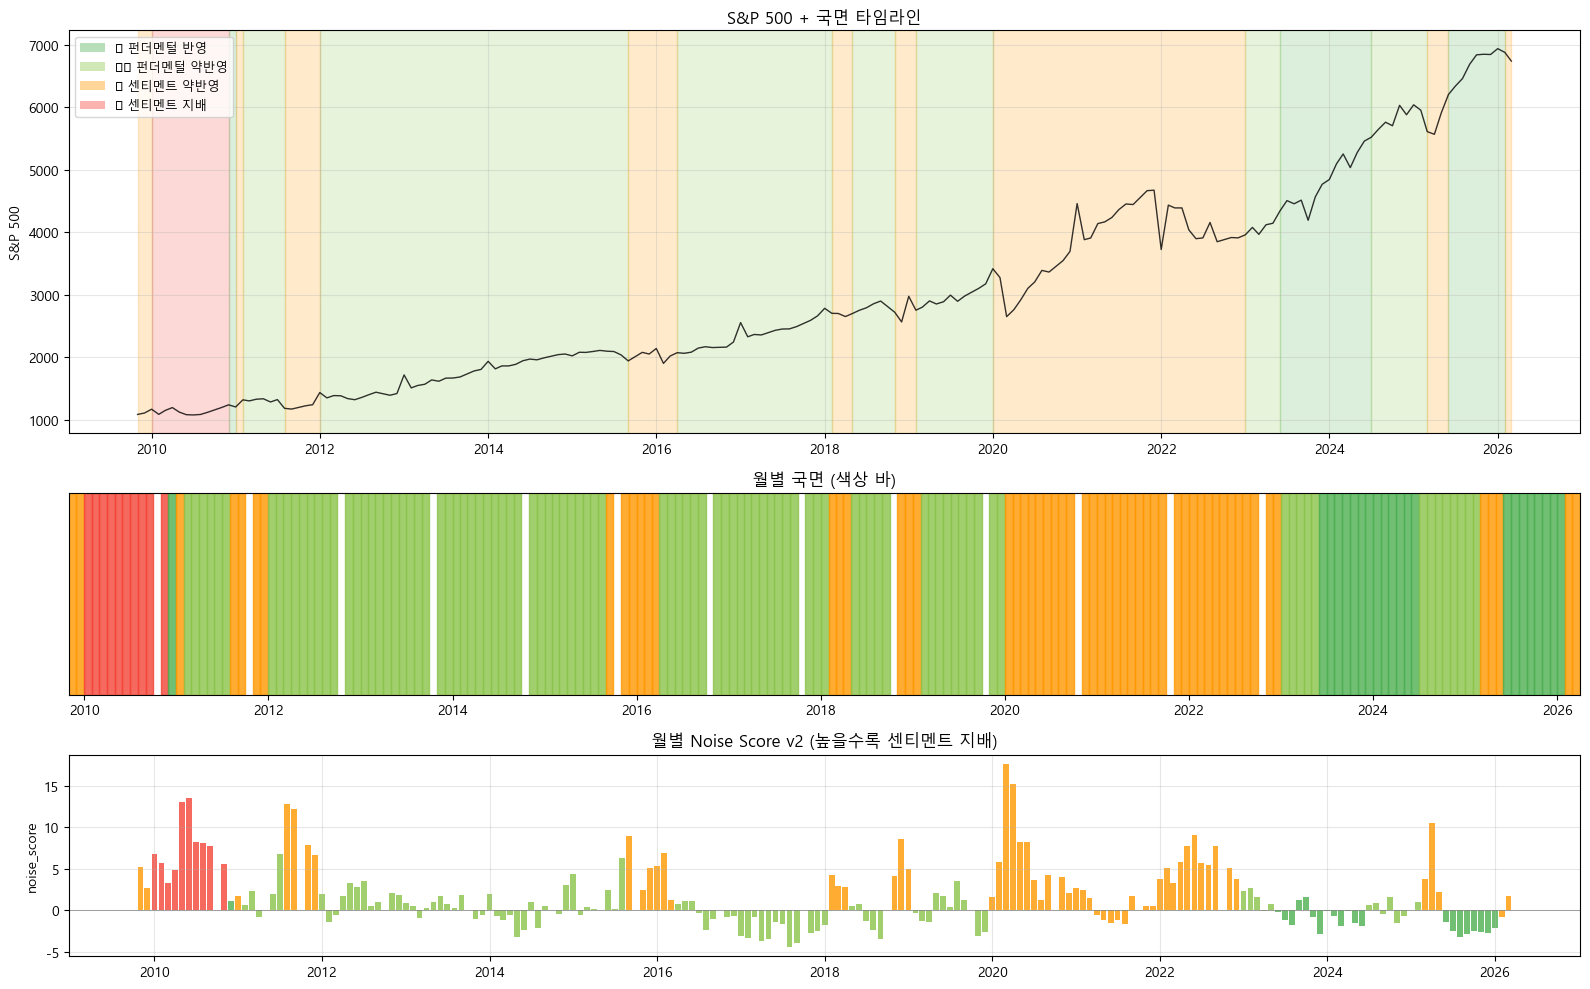



국면 전환 이벤트
  2010-01  🌊 센티멘트 약반영 → 🔥 센티멘트 지배
  2010-12  🔥 센티멘트 지배 → 🧠 펀더멘털 반영
  2011-01  🧠 펀더멘털 반영 → 🌊 센티멘트 약반영
  2011-02  🌊 센티멘트 약반영 → ⚖️ 펀더멘털 약반영
  2011-08  ⚖️ 펀더멘털 약반영 → 🌊 센티멘트 약반영
  2012-01  🌊 센티멘트 약반영 → ⚖️ 펀더멘털 약반영
  2015-09  ⚖️ 펀더멘털 약반영 → 🌊 센티멘트 약반영
  2016-04  🌊 센티멘트 약반영 → ⚖️ 펀더멘털 약반영
  2018-02  ⚖️ 펀더멘털 약반영 → 🌊 센티멘트 약반영
  2018-05  🌊 센티멘트 약반영 → ⚖️ 펀더멘털 약반영
  2018-11  ⚖️ 펀더멘털 약반영 → 🌊 센티멘트 약반영
  2019-02  🌊 센티멘트 약반영 → ⚖️ 펀더멘털 약반영
  2020-01  ⚖️ 펀더멘털 약반영 → 🌊 센티멘트 약반영
  2023-01  🌊 센티멘트 약반영 → ⚖️ 펀더멘털 약반영
  2023-06  ⚖️ 펀더멘털 약반영 → 🧠 펀더멘털 반영
  2024-07  🧠 펀더멘털 반영 → ⚖️ 펀더멘털 약반영
  2025-03  ⚖️ 펀더멘털 약반영 → 🌊 센티멘트 약반영
  2025-06  🌊 센티멘트 약반영 → 🧠 펀더멘털 반영
  2026-02  🧠 펀더멘털 반영 → 🌊 센티멘트 약반영

총 184개월, 국면 전환 19회


In [ ]:
# ── Cell 15: 과거 월별 국면 분류 히스토리 ──────────────────────────────────
from matplotlib.patches import Patch

# ── 월별 국면 테이블 ──
history = features[FEATURE_NAMES + ['phase']].copy()
history['국면'] = history['phase'].map(PHASE_NAMES)
history.index.name = '날짜'

# 연도별 그룹으로 출력
print('과거 월별 국면 분류')
print('=' * 90)
for year in sorted(history.index.year.unique()):
    rows = history[history.index.year == year]
    print(f'\n📅 {year}년')
    print(f'  {"월":>4s}  {"국면":20s}  {"펀더멘털괴리":>10s}  {"ERP Z":>8s}  {"잔차상관":>8s}  {"HY OAS":>8s}  {"실현Vol":>8s}')
    print(f'  {"─"*4}  {"─"*20}  {"─"*10}  {"─"*8}  {"─"*8}  {"─"*8}  {"─"*8}')
    for dt, row in rows.iterrows():
        print(f'  {dt.month:4d}  {row["국면"]:20s}  {row["fundamental_gap"]:+10.4f}  {row["erp_zscore"]:8.4f}  {row["residual_corr"]:8.4f}  {row["hy_spread"]:8.2f}  {row["realized_vol"]:8.3f}')

# ── 타임라인 시각화 ──
fig, axes = plt.subplots(3, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1, 1]})

# [상] S&P 500 + 국면 배경색
sp_sorted = shiller['P'].sort_index()
sp_aligned = sp_sorted.reindex(history.index, method='ffill')

axes[0].plot(history.index, sp_aligned, color='black', linewidth=1, alpha=0.8)
prev_phase = None
span_start = history.index[0]
for i, (dt, row) in enumerate(history.iterrows()):
    ph = row['phase']
    if ph != prev_phase and prev_phase is not None:
        axes[0].axvspan(span_start, dt, alpha=0.2, color=PHASE_COLORS[prev_phase])
        span_start = dt
    prev_phase = ph
axes[0].axvspan(span_start, history.index[-1], alpha=0.2, color=PHASE_COLORS[prev_phase])
axes[0].set_title('S&P 500 + 국면 타임라인')
axes[0].set_ylabel('S&P 500')
axes[0].grid(alpha=0.3)

legend_elements = [Patch(facecolor=PHASE_COLORS[k], alpha=0.4, label=PHASE_NAMES[k]) for k in range(4)]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=9)

# [중] 국면 스트립
for i, (dt, row) in enumerate(history.iterrows()):
    axes[1].axvspan(dt, dt + pd.DateOffset(months=1), color=PHASE_COLORS[row['phase']], alpha=0.8)
axes[1].set_yticks([])
axes[1].set_title('월별 국면 (색상 바)')
axes[1].set_xlim(history.index[0], history.index[-1] + pd.DateOffset(months=1))

# [하] noise_score 추정
monthly_noise = []
for dt, row in history.iterrows():
    vals = row[FEATURE_NAMES].values.astype(float)
    scaled = scaler.transform(vals.reshape(1, -1))
    ns = compute_noise_score(scaled)[0]
    monthly_noise.append(ns)

history['noise_score'] = monthly_noise
axes[2].bar(history.index, history['noise_score'],
            width=25, color=[PHASE_COLORS[p] for p in history['phase']], alpha=0.8)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_title('월별 Noise Score v2 (높을수록 센티멘트 지배)')
axes[2].set_ylabel('noise_score')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── 국면 전환 이벤트 ──
print('\n\n국면 전환 이벤트')
print('=' * 60)
prev = None
for dt, row in history.iterrows():
    ph = row['phase']
    if ph != prev and prev is not None:
        print(f'  {dt.strftime("%Y-%m")}  {PHASE_NAMES[prev]} → {PHASE_NAMES[ph]}')
    prev = ph
print(f'\n총 {len(history)}개월, 국면 전환 {sum(1 for i in range(1, len(history)) if history["phase"].iloc[i] != history["phase"].iloc[i-1])}회')

(A) noise_score v2 변수 기여도 분해 (scaled × 가중치)
      상태  국면                        총점  |fund_gap|×0.5     |erp_z|×0.3  resid_corr×1.0          disp×0      amihud×0.5    vix_term×2.0     hy_sprd×1.5    real_vol×2.0
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
state 0  ⚖️ 펀더멘털 약반영            -0.23           0.003           0.004          -0.235           0.000           0.139          -0.071           0.149          -0.218
state 1  🔥 센티멘트 지배               7.66           4.066           0.036          -0.815           0.000           0.434           0.614           1.831           1.491
state 2  🌊 센티멘트 약반영              4.02           0.151           0.022           0.513           0.000          -0.047           0.611           0.549           2.219
state 3  🧠 펀더멘털 반영              -1.42           0.175           0.297           0.004           0.000          -0.351       

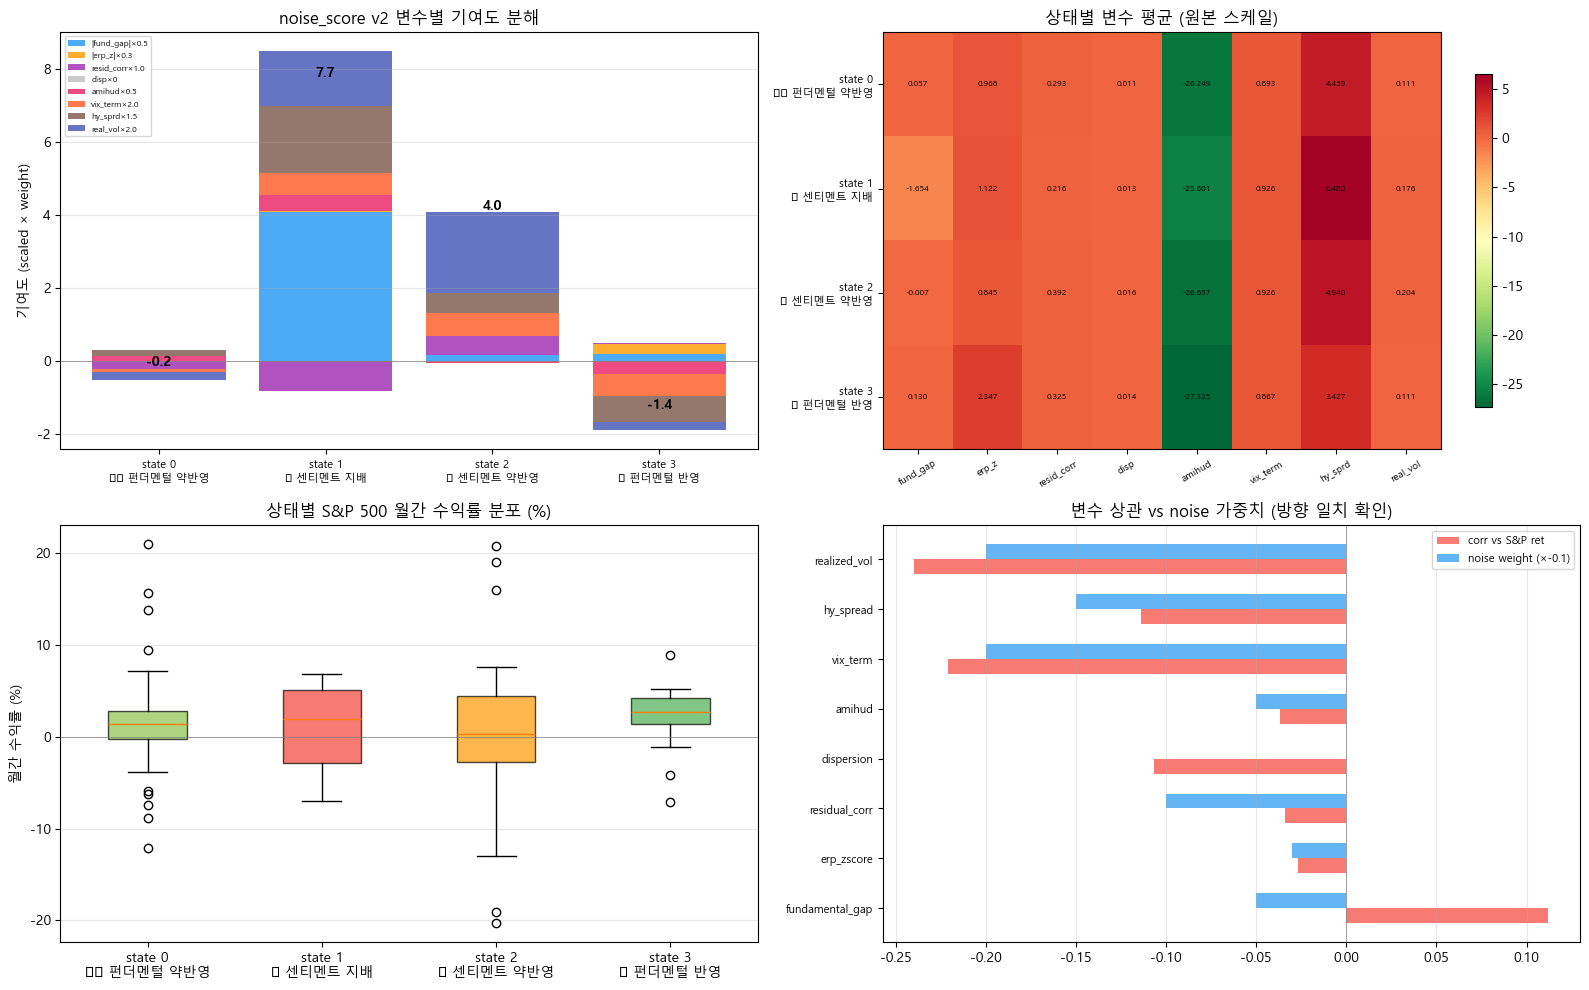



(E) noise_score v1 → v2 변경 요약

v1 문제점 → v2 해결:
  1. |fund_gap| 가중치 1.0 → 0.5 (corr=+0.11, 수익률과 양의 상관 → 축소)
  2. |erp_zscore| 가중치 1.0 → 0.3 (corr≈0, 거의 무관 → 대폭 축소)
  3. -dispersion 가중치 -1.0 → 0 (방향 왜곡 유발 → 제거)
  4. vix_term 가중치 1.0 → 2.0 (corr=-0.22, 가장 강한 상관 → 상향)
  5. hy_spread 가중치 1.0 → 1.5 (corr=-0.13 → 상향)
  6. realized_vol 신규 추가 (가중치 2.0, 변동성 = 가장 직접적 noise 지표)



In [ ]:
# ── Cell 16: noise_score v2 진단 — 상태별 변수 기여도 분해 ──────────────────
from matplotlib.patches import Patch

# ── (A) 상태별 noise_score 변수 기여도 분해 ──
contrib_labels = ['|fund_gap|×0.5', '|erp_z|×0.3', 'resid_corr×1.0',
                  'disp×0', 'amihud×0.5', 'vix_term×2.0', 'hy_sprd×1.5', 'real_vol×2.0']

def decompose_noise_v2(means_scaled):
    """각 변수의 noise_score v2 기여분."""
    return np.column_stack([
        0.5 * np.abs(means_scaled[:, 0]),
        0.3 * np.abs(means_scaled[:, 1]),
        1.0 * means_scaled[:, 2],
        np.zeros(len(means_scaled)),       # dispersion 제거
        0.5 * means_scaled[:, 4],
        2.0 * means_scaled[:, 5],
        1.5 * means_scaled[:, 6],
        2.0 * means_scaled[:, 7],
    ])

contrib = decompose_noise_v2(model.means_)
means_orig = scaler.inverse_transform(model.means_)

print('(A) noise_score v2 변수 기여도 분해 (scaled × 가중치)')
print('=' * 110)
header = f'{"상태":>8s}  {"국면":20s}  {"총점":>6s}  ' + '  '.join(f'{l:>14s}' for l in contrib_labels)
print(header)
print('-' * len(header))

for sid in range(N_STATES):
    ph = state_to_phase[sid]
    ns = noise_scores[sid]
    c = contrib[sid]
    row = f'state {sid:d}  {PHASE_NAMES[ph]:20s}  {ns:6.2f}  '
    row += '  '.join(f'{v:14.3f}' for v in c)
    print(row)

# ── (B) 상태별 연도 분포 ──
print('\n\n(B) 상태별 해당 시기')
print('=' * 70)
for sid in range(N_STATES):
    ph = state_to_phase[sid]
    mask = features['state'] == sid
    dates = features.index[mask]
    year_counts = pd.Series(dates.year).value_counts().sort_index()
    periods = [f'{y}({cnt})' for y, cnt in year_counts.items()]
    print(f'  state {sid} → {PHASE_NAMES[ph]}')
    print(f'    기간: {", ".join(periods)}  |  총 {len(dates)}개월')

# ── (C) 상태별 S&P 500 수익률 대조 ──
print('\n\n(C) 상태별 S&P 500 월간 수익률')
print('=' * 70)
sp_ret = shiller['P'].sort_index().pct_change()
sp_ret_aligned = sp_ret.reindex(features.index)

for sid in range(N_STATES):
    ph = state_to_phase[sid]
    mask = features['state'] == sid
    rets = sp_ret_aligned[mask].dropna()
    pos_pct = (rets > 0).mean() * 100
    print(f'  state {sid} → {PHASE_NAMES[ph]}:')
    print(f'    평균: {rets.mean()*100:+.2f}%  중위수: {rets.median()*100:+.2f}%  '
          f'최대: {rets.max()*100:+.1f}%  최소: {rets.min()*100:+.1f}%  상승월: {pos_pct:.0f}%')

# ── (D) 시각화 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# [좌상] 변수별 기여도 스택바
x = np.arange(N_STATES)
state_labels = [f'state {sid}\n{PHASE_NAMES[state_to_phase[sid]]}' for sid in range(N_STATES)]
colors_contrib = ['#2196F3', '#FF9800', '#9C27B0', '#BDBDBD', '#E91E63', '#FF5722', '#795548', '#3F51B5']
bottom_pos = np.zeros(N_STATES)
bottom_neg = np.zeros(N_STATES)

for j in range(8):
    vals = contrib[:, j]
    pos_vals = np.where(vals >= 0, vals, 0)
    neg_vals = np.where(vals < 0, vals, 0)
    axes[0, 0].bar(x, pos_vals, bottom=bottom_pos, color=colors_contrib[j],
                   alpha=0.8, label=contrib_labels[j])
    axes[0, 0].bar(x, neg_vals, bottom=bottom_neg, color=colors_contrib[j], alpha=0.8)
    bottom_pos += pos_vals
    bottom_neg += neg_vals

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(state_labels, fontsize=8)
axes[0, 0].set_title('noise_score v2 변수별 기여도 분해')
axes[0, 0].set_ylabel('기여도 (scaled × weight)')
axes[0, 0].legend(fontsize=6, loc='upper left')
axes[0, 0].axhline(0, color='gray', linewidth=0.5)
axes[0, 0].grid(axis='y', alpha=0.3)
for i in range(N_STATES):
    axes[0, 0].text(i, noise_scores[i] + 0.1, f'{noise_scores[i]:.1f}',
                    ha='center', fontsize=10, fontweight='bold')

# [우상] 상태별 원본 변수 평균 히트맵
orig_labels = ['fund_gap', 'erp_z', 'resid_corr', 'disp', 'amihud', 'vix_term', 'hy_sprd', 'real_vol']
im = axes[0, 1].imshow(means_orig, cmap='RdYlGn_r', aspect='auto')
axes[0, 1].set_yticks(range(N_STATES))
axes[0, 1].set_yticklabels(state_labels, fontsize=8)
axes[0, 1].set_xticks(range(8))
axes[0, 1].set_xticklabels(orig_labels, fontsize=7, rotation=30)
axes[0, 1].set_title('상태별 변수 평균 (원본 스케일)')
for i in range(N_STATES):
    for j in range(8):
        axes[0, 1].text(j, i, f'{means_orig[i, j]:.3f}', ha='center', va='center', fontsize=6)
plt.colorbar(im, ax=axes[0, 1], shrink=0.8)

# [좌하] 상태별 S&P 500 수익률 박스플롯
bp_data = []
bp_labels = []
bp_colors = []
for sid in range(N_STATES):
    ph = state_to_phase[sid]
    mask = features['state'] == sid
    rets = sp_ret_aligned[mask].dropna() * 100
    bp_data.append(rets.values)
    bp_labels.append(f'state {sid}\n{PHASE_NAMES[ph]}')
    bp_colors.append(PHASE_COLORS[ph])

bplot = axes[1, 0].boxplot(bp_data, labels=bp_labels, patch_artist=True, showfliers=True)
for patch, color in zip(bplot['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].axhline(0, color='gray', linewidth=0.5)
axes[1, 0].set_title('상태별 S&P 500 월간 수익률 분포 (%)')
axes[1, 0].set_ylabel('월간 수익률 (%)')
axes[1, 0].grid(axis='y', alpha=0.3)

# [우하] 변수 vs 수익률 상관 + 가중치 비교
corr_vals = []
weight_vals = [0.5, 0.3, 1.0, 0.0, 0.5, 2.0, 1.5, 2.0]
for fname in FEATURE_NAMES:
    corr_vals.append(features[fname].corr(sp_ret_aligned))

y = np.arange(8)
axes[1, 1].barh(y - 0.15, corr_vals, height=0.3, color='#F44336', alpha=0.7, label='corr vs S&P ret')
axes[1, 1].barh(y + 0.15, [-w/10 for w in weight_vals], height=0.3, color='#2196F3', alpha=0.7, label='noise weight (×-0.1)')
axes[1, 1].set_yticks(y)
axes[1, 1].set_yticklabels(FEATURE_NAMES, fontsize=8)
axes[1, 1].axvline(0, color='gray', linewidth=0.5)
axes[1, 1].set_title('변수 상관 vs noise 가중치 (방향 일치 확인)')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ── (E) v1 vs v2 비교 요약 ──
print('\n\n(E) noise_score v1 → v2 변경 요약')
print('=' * 70)
print('''
v1 문제점 → v2 해결:
  1. |fund_gap| 가중치 1.0 → 0.5 (corr=+0.11, 수익률과 양의 상관 → 축소)
  2. |erp_zscore| 가중치 1.0 → 0.3 (corr≈0, 거의 무관 → 대폭 축소)
  3. -dispersion 가중치 -1.0 → 0 (방향 왜곡 유발 → 제거)
  4. vix_term 가중치 1.0 → 2.0 (corr=-0.22, 가장 강한 상관 → 상향)
  5. hy_spread 가중치 1.0 → 1.5 (corr=-0.13 → 상향)
  6. realized_vol 신규 추가 (가중치 2.0, 변동성 = 가장 직접적 noise 지표)
''')